### These: 
#### Länder mit höherem BIP pro Kopf haben eine höhere Lebenserwartung. Dargestellt in einem direkten Vergleich von jeweils 2 Ländern mit unterschiedlichem BIP pro Kopf und ähnlicher Einwohnerzahl

In [93]:
#Wichtige Imports
import pandas as pd
import matplotlib.pyplot as plt
import re

In [94]:
# Load WHO mortality data
df = pd.read_csv("Data_Files/country_lookup.csv")

# Keep only the columns we really need
df = df[["Country", "Year", "Cause", "Deaths1"]]

# Check how big the data is
print("Rows:", len(df))
print("Columns:", df.columns.tolist())


Rows: 4710902
Columns: ['Country', 'Year', 'Cause', 'Deaths1']


In [95]:
# Make sure the column is numeric
df["Deaths1"] = pd.to_numeric(df["Deaths1"], errors="coerce")

# Count missing and zero values safely
num_missing = df["Deaths1"].isna().sum()
num_zeros = (df["Deaths1"] == 0).sum()

print(f"{num_missing} NaN values in 'Deaths at all ages'")
print(f"{num_zeros} zeros in 'Deaths at all ages'")


0 NaN values in 'Deaths at all ages'
7602 zeros in 'Deaths at all ages'


In [96]:
#Wieviele Länder sind im Datensatz enthalten?
df["Country"].nunique()

124

In [97]:
#Welche Länder sind im Datensatz enthalten?
sorted(df["Country"].unique())

['Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Bahamas',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Bermuda',
 'Bolivia',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Canada',
 'Cayman Islands',
 'Chile',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'El Salvador',
 'Estonia',
 'Fiji',
 'France',
 'French Guiana',
 'Georgia',
 'Germany',
 'Greece',
 'Grenada',
 'Guadeloupe',
 'Guatemala',
 'Guyana',
 'Haiti',
 'Honduras',
 'Hong Kong SAR',
 'Hungary',
 'Iceland',
 'Iran (Islamic Republic of)',
 'Ireland',
 'Israel',
 'Italy',
 'Jamaica',
 'Japan',
 'Jordan',
 'Kazakhstan',
 'Kiribati',
 'Kuwait',
 'Kyrgyzstan',
 'Latvia',
 'Lebanon',
 'Lithuania',
 'Luxembourg',
 'Maldives',
 'Malta',
 'Martinique',
 'Mauritius',
 'Mayotte',
 'Mexico',
 'Micronesia (Federated States of)',
 'Mongolia',
 'Mont

In [98]:
#Wieviele Einträge pro Land sind im Datensatz enthalten?
df["Country"].value_counts()


Country
Brazil                       307521
United States of America     160718
Mexico                       155631
Japan                        139281
Germany                      135943
                              ...  
Qatar                           710
Montenegro                      624
Kiribati                        469
Solomon Islands                 463
Saint Pierre and Miquelon       209
Name: count, Length: 124, dtype: int64

In [99]:
#Wie viele Jahre sind pro Land im Datensatz enthalten?
coverage = df.groupby("Country")["Year"].nunique().reset_index(name="Years_Reported").sort_values("Years_Reported", ascending=False)
print(coverage)


                        Country  Years_Reported
27               Czech Republic              30
28                      Denmark              29
109                 Switzerland              28
47                      Hungary              28
65                        Malta              27
..                          ...             ...
14                     Botswana               1
49   Iran (Islamic Republic of)               1
9                       Belarus               1
100                      Serbia               1
89                        Qatar               1

[124 rows x 2 columns]


✅ Years covered: 2010–2020


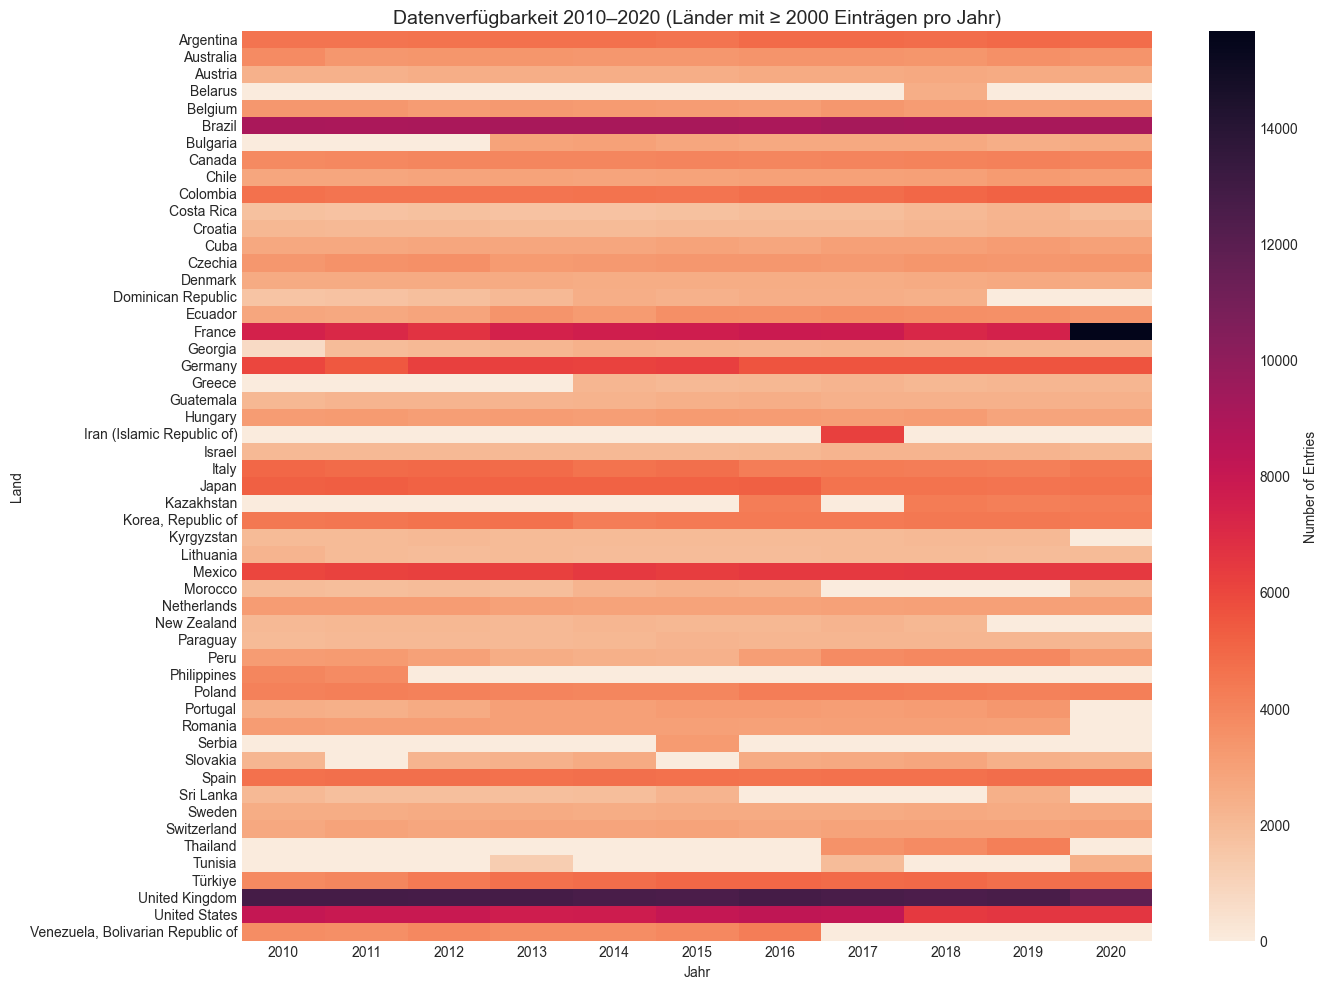

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️⃣ Load and prepare the dataset ---
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv", low_memory=False)
df = df.rename(columns={"Deaths at all ages": "Deaths1"})

# Ensure numeric year and drop rows missing country or year
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Country", "Year"])

# --- 2️⃣ Country name harmonization ---
country_map = {
    "United States of America": "United States",
    "Czech Republic": "Czechia",
    "Republic of Korea": "Korea, Republic of",
    "Republic of Moldova": "Moldova",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "United Kingdom, England and Wales": "United Kingdom",
    "United Kingdom, Scotland": "United Kingdom",
    "United Kingdom, Northern Ireland": "United Kingdom",
    "Hong Kong SAR": "Hong Kong",
    "Reunion": "France",
    "Guadeloupe": "France",
    "Martinique": "France",
    "Mayotte": "France",
    "French Guiana": "France",
    "Rodrigues": "Mauritius",
    "Puerto Rico": "United States",
    "Virgin Islands (USA)": "United States"
}

df["Country_clean"] = df["Country"].replace(country_map)

# --- 3️⃣ Group by country and year ---
count_df = (
    df.groupby(["Country_clean", "Year"])
    .size()
    .reset_index(name="Entries")
)

# --- 4️⃣ Build full pivot table ---
all_countries = sorted(df["Country_clean"].unique())
all_years = sorted(df["Year"].unique())

heatmap_data = (
    count_df.pivot(index="Country_clean", columns="Year", values="Entries")
    .reindex(index=all_countries, columns=all_years)
    .fillna(0)
)

# --- 5️⃣ Filter for years 2010–2020 ---
years_filter = [y for y in heatmap_data.columns if 2010 <= y <= 2020]
filtered_years_data = heatmap_data[years_filter]

# --- 6️⃣ Drop countries with fewer than 2000 entries total (any year) ---
threshold = 2000
filtered_heatmap_data = filtered_years_data[filtered_years_data.max(axis=1) >= threshold]

print(f"✅ Years covered: {filtered_heatmap_data.columns.min()}–{filtered_heatmap_data.columns.max()}")

# --- 7️⃣ Plot the cleaned heatmap ---
plt.figure(figsize=(14, 10))
sns.heatmap(
    filtered_heatmap_data,
    cmap="rocket_r",  # high-contrast palette
    cbar_kws={"label": "Number of Entries"},
    linewidths=0.0
)
plt.title("Datenverfügbarkeit 2010–2020 (Länder mit ≥ 2000 Einträgen pro Jahr)", fontsize=14)
plt.xlabel("Jahr")
plt.ylabel("Land")
plt.tight_layout()
plt.show()


In [101]:


# filter year 2017
df_2017 = df[df["Year"] == 2017]

# count entries per country
counts = df_2017["Country"].value_counts()

print(counts)


Country
Brazil                        9230
Mexico                        6441
United States of America      6415
Iran (Islamic Republic of)    6205
Germany                       5589
                              ... 
Rodrigues                      109
British Virgin Islands          84
Turks and Caicos Islands        75
Anguilla                        67
Montserrat                      30
Name: count, Length: 93, dtype: int64


In [102]:
country_map = {
    "United States of America": "United States",
    "Czech Republic": "Czechia",
    "Republic of Korea": "Korea, Republic of",
    "Republic of Moldova": "Moldova",
    "Turkey": "Türkiye",
    "Venezuela": "Venezuela, Bolivarian Republic of",
    "United Kingdom, England and Wales": "United Kingdom",
    "United Kingdom, Scotland": "United Kingdom",
    "United Kingdom, Northern Ireland": "United Kingdom",
    "Hong Kong SAR": "Hong Kong",
    "Reunion": "France",
    "Guadeloupe": "France",
    "Martinique": "France",
    "Mayotte": "France",
    "French Guiana": "France",
    "Rodrigues": "Mauritius",
    "Puerto Rico": "United States",
    "Virgin Islands (USA)": "United States"
}

df["Country_clean"] = df["Country"].replace(country_map)

# --- Find all unique available countries (after cleaning) ---
all_countries = sorted(df["Country_clean"].dropna().unique())
print(f"🌍 Found {len(all_countries)} countries in dataset")

# --- Keep only data for year 2017 ---
df_2017 = df[df["Year"] == 2017].copy()

# --- Drop missing or 0-death rows for clean results ---
df_2017 = df_2017[df_2017["Deaths1"].fillna(0) > 0]

print(f"✅ After filtering: {len(df_2017):,} rows left for year 2017")
print(f"🌐 Countries included: {df_2017['Country_clean'].nunique()}")

# --- Optional sanity check ---




🌍 Found 113 countries in dataset
✅ After filtering: 208,555 rows left for year 2017
🌐 Countries included: 82


In [103]:
df["Cause"] = df["Cause"].astype(str).str.strip().str.upper()


df_ohni_doppelt = df[~df["Cause"].str.fullmatch(r"[A-Z]{3}")]





In [104]:
def categorize_icd10(code):
    c = str(code).strip().upper()

    # Extract first letter
    first = c[0]

    # -----------------------------
    # Communicable diseases
    # -----------------------------
    if first in ["A", "B"]:
        return "Communicable Diseases"

    # -----------------------------
    # Noncommunicable diseases (C–N)
    # -----------------------------
    if first in list("CDEFGHIJKLMN"):
        return "Noncommunicable Diseases"

    # -----------------------------
    # Injuries (S, T + external causes V, W, X, Y)
    # -----------------------------
    if first in list("STVWXY"):
        return "Injuries & External Causes"

    # -----------------------------
    # Other / Special categories (O, P, Q, R, Z, U)
    # -----------------------------
    return "Other/Unclassified"


In [105]:
df_ohni_doppelt["Category"] = df_ohni_doppelt["Cause"].apply(categorize_icd10)


/var/folders/37/084722ds0s5f0lsp5b75z_w40000gn/T/ipykernel_34792/3515409988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ohni_doppelt["Category"] = df_ohni_doppelt["Cause"].apply(categorize_icd10)


In [107]:
# Rebuild detailed-level dataframe with Cause
df_total = (
    df_ohni_doppelt
    .groupby(["Country_clean", "Year", "Cause"], as_index=False)["Deaths1"]
    .sum()
)

# Reapply your categorization function
df_total["Category"] = df_total["Cause"].apply(categorize_icd10)


In [108]:
# Add up all deaths within each category for each country and year
df_grouped = (
    df_ohni_doppelt
    .groupby(["Country", "Year", "Category"], as_index=False)["Deaths1"]
    .sum()
)

# Calculate percentage share inside each country-year
df_grouped["Percent"] = (
    df_grouped["Deaths1"] /
    df_grouped.groupby(["Country", "Year"])["Deaths1"].transform("sum") * 100
)


In [111]:
swiss_2017 = (
    df_grouped[(df_grouped["Country"] == "Switzerland") & (df_grouped["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(swiss_2017)

kyrgyzstan_2017 = (
    df_grouped[(df_grouped["Country"] == "Kyrgyzstan") & (df_grouped["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(kyrgyzstan_2017)

brazil_2017 = (
    df_grouped[(df_grouped["Country"] == "Brazil") & (df_grouped["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(brazil_2017)



KeyError: 'Country'

In [69]:
peru_2017 = (
    df_grouped[(df_grouped["Country"] == "Peru") & (df_grouped["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(peru_2017)

germany_2017 = (
    df_grouped[(df_grouped["Country"] == "Germany") & (df_grouped["Year"] == 2017)]
    .sort_values("Percent", ascending=False)
)
print(germany_2017)

     Country  Year                    Category  Deaths1    Percent
6034    Peru  2017    Noncommunicable Diseases   173370  71.556520
6033    Peru  2017  Injuries & External Causes    43309  17.875303
6032    Peru  2017       Communicable Diseases    18846   7.778475
6035    Peru  2017          Other/Unclassified     6759   2.789701
      Country  Year                    Category  Deaths1    Percent
2990  Germany  2017    Noncommunicable Diseases  1420341  76.176320
2988  Germany  2017       Communicable Diseases   185785   9.964098
2989  Germany  2017  Injuries & External Causes   170877   9.164546
2991  Germany  2017          Other/Unclassified    87541   4.695035


In [70]:
# Select data for the country and year range
swiss_all = (
    df_grouped[
        (df_grouped["Country"] == "Switzerland") &
        (df_grouped["Year"] == 2017)
    ]
    .groupby(["Country", "Category"], as_index=False)["Deaths1"].sum()
)

# Compute percent within the total
swiss_all["Percent"] = (
    swiss_all["Deaths1"] /
    swiss_all["Deaths1"].sum() * 100
)

print(swiss_all.sort_values("Percent", ascending=False))


# 1️⃣ Work on the base dataset that still has ICD codes
df["Cause"] = df["Cause"].astype(str).str.strip().str.upper()

# 2️⃣ Filter for “Other/Unclassified” BEFORE aggregation
df_other = df[df["Category"] == "Other/Unclassified"].copy()

# 3️⃣ Extract first ICD-10 letter
df_other["First_Letter"] = df_other["Cause"].str[0]

# 4️⃣ Check letter distribution
print("ICD-10 first-letter distribution among 'Other/Unclassified':")
print(df_other["First_Letter"].value_counts())

# 5️⃣ Optional — inspect top causes
top_other_causes = (
    df_other.groupby("Cause", as_index=False)["Deaths1"]
    .sum()
    .sort_values("Deaths1", ascending=False)
    .head(15)
)
print("\nTop 15 'Other/Unclassified' causes:")
print(top_other_causes)



       Country                    Category  Deaths1    Percent
2  Switzerland    Noncommunicable Diseases   107854  80.522913
1  Switzerland  Injuries & External Causes    12487   9.322692
0  Switzerland       Communicable Diseases     7553   5.639008
3  Switzerland          Other/Unclassified     6048   4.515387
ICD-10 first-letter distribution among 'Other/Unclassified':
First_Letter
U    153483
Z      4783
4       140
Name: count, dtype: int64

Top 15 'Other/Unclassified' causes:
                                                 Cause  Deaths1
85                                UNSPECIFIED DEMENTIA  5947681
96   UNSPECIFIED DIABETES MELLITUS: WITHOUT COMPLIC...  3411847
22                                    UNATTENDED DEATH  2191593
200        URINARY TRACT INFECTION, SITE NOT SPECIFIED  1651927
107                         UNSPECIFIED KIDNEY FAILURE  1277866
94   UNSPECIFIED DIABETES MELLITUS: WITH RENAL COMP...  1182681
92   UNSPECIFIED DIABETES MELLITUS: WITH OTHER SPEC...   600335


Um zwischen Ländern mit höherem und mittlerem Einkommen zu unterscheiden, werden wir die Einkommensklassifikation der Weltbank verwenden. Dort werden die Schweiz, Japan, Portugal, Kanada, Schweden und Süd Korea (Republik Korea) als High-Income Länder eingestuft, während Polen, Rumänien, Mexico und Kolumbien zu den Middle-Income Länder zählen.

Quelle: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519


 Share of deaths by cause (aggregated by defined year ranges)

    Country  Communicable Diseases  Injuries & External Causes  Noncommunicable Diseases  Other/Unclassified
Switzerland                   7.85                        9.85                     79.84                2.46
      Japan                   5.55                       13.97                     79.00                1.47
     Canada                  11.11                        9.06                     76.54                3.29
     Mexico                   9.27                       13.52                     72.54                4.68
   Colombia                   8.89                       10.17                     78.02                2.92
     Brazil                   6.99                       14.02                     73.26                5.72
  Nicaragua                   9.41                       14.54                     74.12                1.93
 Kyrgyzstan                  14.40                       17.56  

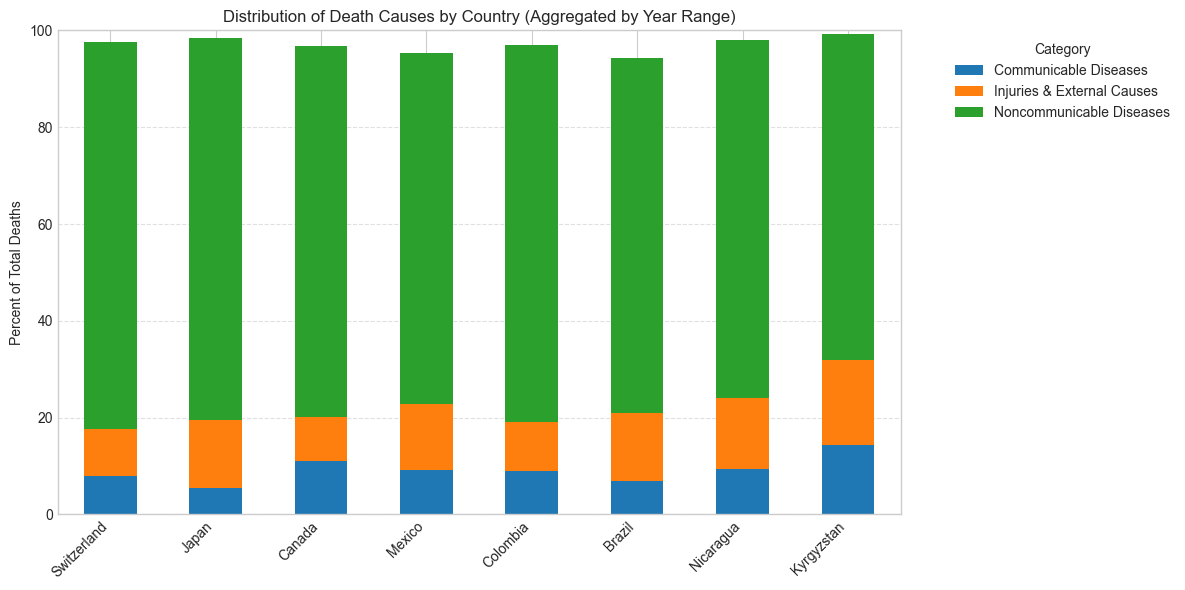

In [71]:
country_year_ranges = {
    "Switzerland": range(2000, 2010),
    "Japan": range(2000, 2010),
    "Canada": range(2000, 2010),
    "Mexico": range(2000, 2010),
    "Colombia": range(2000, 2010),
    "Brazil": range(2000, 2010),
    "Nicaragua": range(2000, 2010),
    "Kyrgyzstan": range(2000, 2010)
}

summary_list = []

for country, year_range in country_year_ranges.items():
    # Filter dataset for that country + year range
    df_sub = df_grouped[
        (df_grouped["Country"] == country)
        & (df_grouped["Year"].isin(year_range))
    ].copy()

    # Aggregate deaths by category across the full range
    df_sum = (
        df_sub.groupby(["Country", "Category"], as_index=False)["Deaths1"].sum()
    )

    # Compute share of total deaths within country
    total_deaths = df_sum["Deaths1"].sum()
    df_sum["Percent"] = (df_sum["Deaths1"] / total_deaths * 100).round(2)

    # Append results
    summary_list.append(df_sum)

# Combine all countries into one DataFrame
summary_all = pd.concat(summary_list, ignore_index=True)

# Sort cleanly
summary_all = summary_all.sort_values(["Country", "Percent"], ascending=[True, False])

summary_all["Deaths1"] = summary_all["Deaths1"].astype(int)
summary_all["Percent"] = summary_all["Percent"].round(2)

table_clean = (
    summary_all
    .pivot(index="Country", columns="Category", values="Percent")
    .fillna(0)
    .round(2)
    .reset_index()
)

# Define a logical country order (by income level)
country_order = [
    "Switzerland", "Japan", "Canada",   # High income
    "Poland", "Mexico", "Colombia",     # Upper middle
    "Brazil", "Turkey",                 # Lower middle
    "Nicaragua", "Kyrgyzstan"           # Low income
]
table_clean["Country"] = pd.Categorical(
    table_clean["Country"], categories=country_order, ordered=True
)
table_clean = table_clean.sort_values("Country")

print("\n Share of deaths by cause (aggregated by defined year ranges)\n")
print(table_clean.to_string(index=False))

# Set category order and colors
category_order = [
    "Communicable Diseases",
    "Injuries & External Causes",
    "Noncommunicable Diseases"
]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Plot stacked bar chart
ax = table_clean.set_index("Country")[category_order].plot(
    kind="bar", stacked=True, color=colors, figsize=(12,6)
)

plt.title("Distribution of Death Causes by Country (Aggregated by Year Range)")
plt.ylabel("Percent of Total Deaths")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [72]:
# Filter for Other/Unclassified causes
other_df = df_total[df_total["Category"] == "Other/Unclassified"].copy()

# Get the first letter of each ICD code
other_df["First_Letter"] = other_df["Cause"].astype(str).str[0]

# See distribution across ICD letters
print("\nLetter distribution in Other/Unclassified:")
print(other_df["First_Letter"].value_counts(normalize=True).round(3) * 100)



Letter distribution in Other/Unclassified:
First_Letter
U    96.1
Z     3.8
4     0.2
Name: proportion, dtype: float64


In [73]:
#CATEGORIZE ICD-10 CODE
df_total["Category"] = df_total["Cause"].apply(categorize_icd10)

# --- DEFINE FUNCTION TO REFINE "OTHER/UNCLASSIFIED" ---
def refine_other(code):
    c = str(code).upper()
    if re.match(r"^O", c): return "Maternal Causes"
    if re.match(r"^P", c): return "Perinatal Conditions"
    if re.match(r"^Q", c): return "Congenital Disorders"
    if re.match(r"^R", c): return "Ill-defined/Unknown Causes"
    if re.match(r"^U", c): return "Special Codes (COVID, etc.)"
    
#ADD NEW SUBCATEGORY COLUMN
df_total["Other_Subcategory"] = df_total["Cause"].apply(refine_other)

#COMBINE INTO A SINGLE BLOCK
#Filter only the 'Other/Unclassified' category
other_df = df_total[df_total["Category"] == "Other/Unclassified"].copy()

#Group by country and the refined subcategory
other_grouped = (
    other_df.groupby(["Country", "Other_Subcategory"], as_index=False)["Deaths1"]
    .sum()
)

#Calculate within-country percentages
other_grouped["Percent"] = (
    other_grouped["Deaths1"] /
    other_grouped.groupby("Country")["Deaths1"].transform("sum") * 100
).round(2)

#Sort results by country and descending deaths
other_grouped = other_grouped.sort_values(
    ["Country", "Deaths1"], ascending=[True, False]
)

#Display neatly
print("\nBreakdown of 'Other/Unclassified' deaths by subcategory:")
print(other_grouped.to_string(index=False))




Breakdown of 'Other/Unclassified' deaths by subcategory:
    Country           Other_Subcategory  Deaths1  Percent
     Brazil Special Codes (COVID, etc.)  3751499    100.0
     Canada Special Codes (COVID, etc.)   481250    100.0
   Colombia Special Codes (COVID, etc.)   306247    100.0
      Japan Special Codes (COVID, etc.)   994549    100.0
 Kyrgyzstan Special Codes (COVID, etc.)    10961    100.0
     Mexico Special Codes (COVID, etc.)  1183542    100.0
  Nicaragua Special Codes (COVID, etc.)    19242    100.0
     Poland Special Codes (COVID, etc.)   160533    100.0
Switzerland Special Codes (COVID, etc.)   112594    100.0
     Turkey Special Codes (COVID, etc.)   216463    100.0


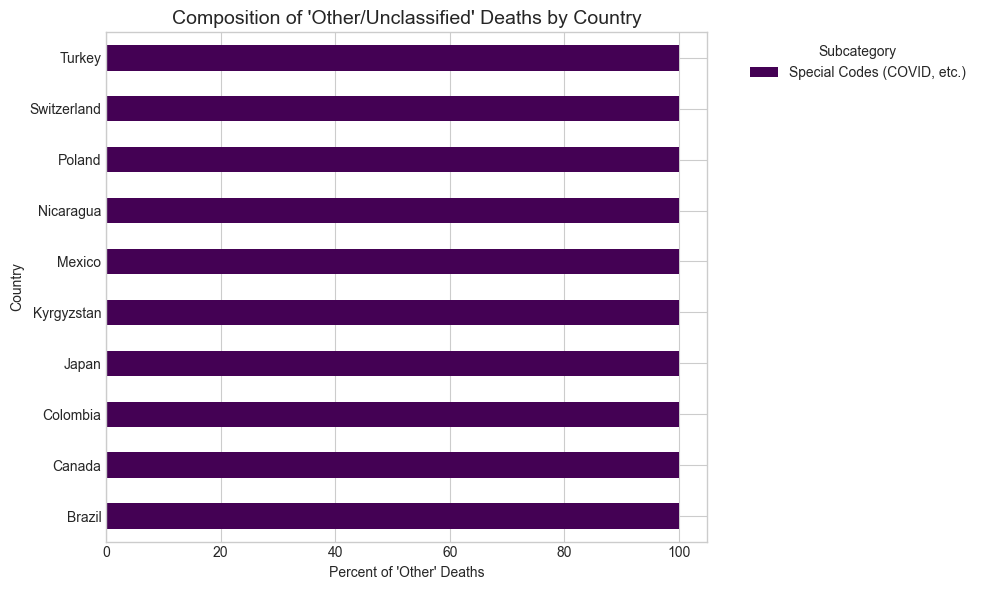

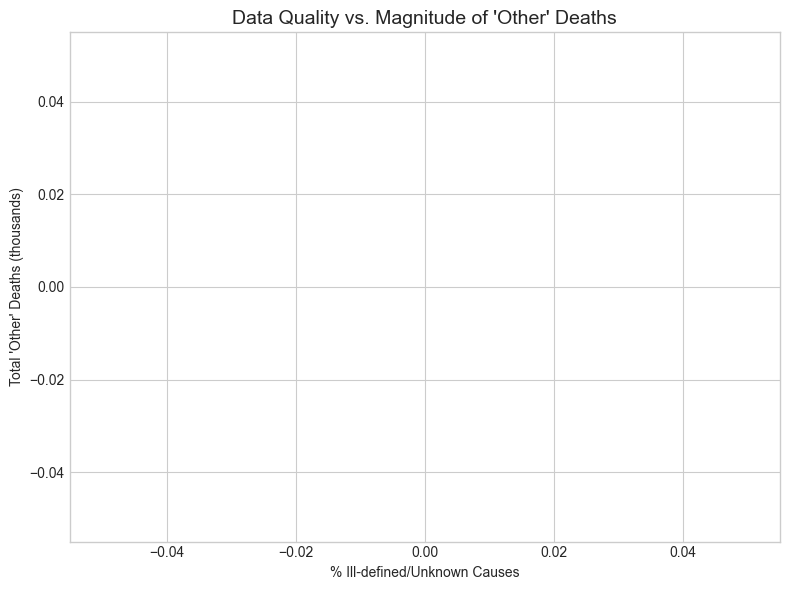

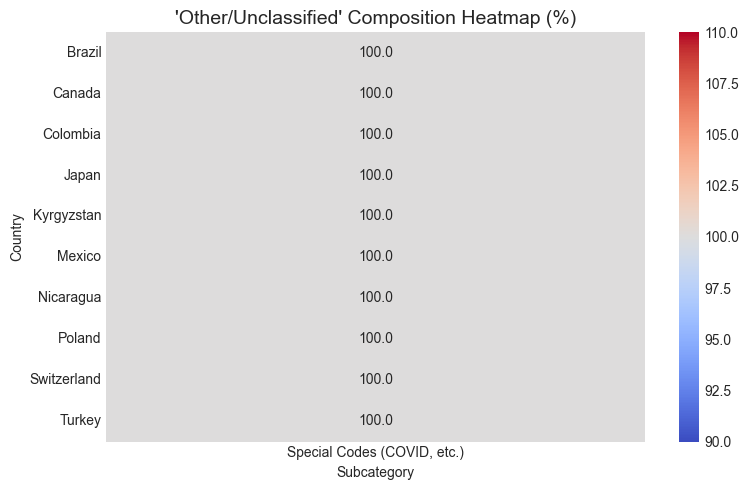

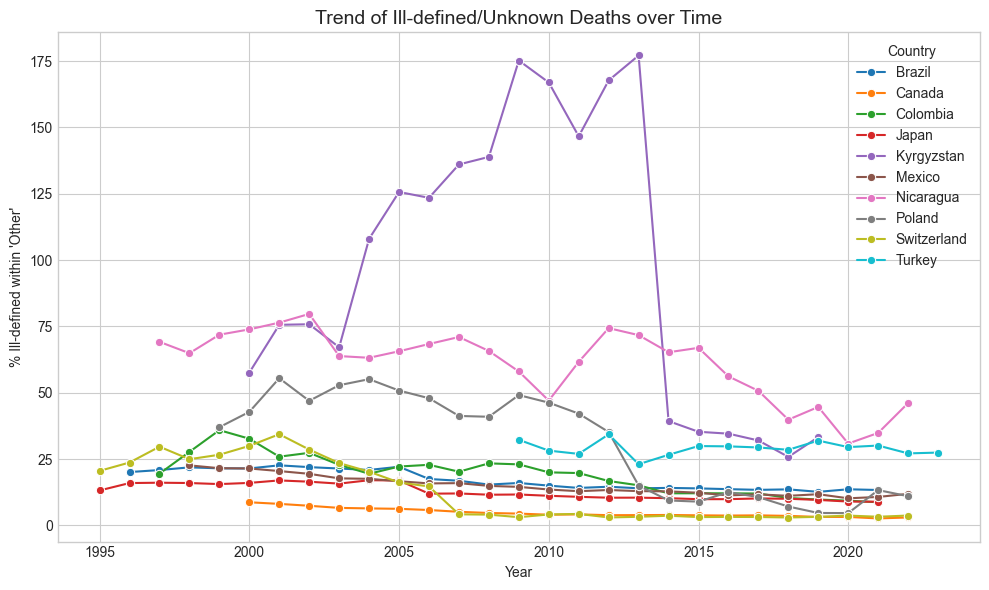

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi
import networkx as nx

plt.style.use("seaborn-v0_8-whitegrid")

# ===============================================
# 1️⃣ Stacked Bar — Clear composition
# ===============================================
plot_df = other_grouped.pivot(
    index="Country", columns="Other_Subcategory", values="Percent"
).fillna(0)

fig, ax = plt.subplots(figsize=(10,6))
plot_df.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Composition of 'Other/Unclassified' Deaths by Country", fontsize=14)
ax.set_xlabel("Percent of 'Other' Deaths")
ax.legend(title="Subcategory", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ===============================================
# 2️⃣ Bubble Plot — Size vs. data quality
# ===============================================
ill = other_grouped[other_grouped["Other_Subcategory"] == "Ill-defined/Unknown Causes"]
totals = other_grouped.groupby("Country", as_index=False)["Deaths1"].sum()
bubbles = totals.merge(ill[["Country", "Percent"]], on="Country", how="left")

plt.figure(figsize=(8,6))
plt.scatter(
    bubbles["Percent"], bubbles["Deaths1"]/1e3,
    s=bubbles["Deaths1"]/1000, c=bubbles["Percent"], cmap="plasma",
    edgecolor="black", alpha=0.7
)
for _, r in bubbles.iterrows():
    plt.text(r["Percent"]+0.3, r["Deaths1"]/1e3, r["Country"], fontsize=9)
plt.title("Data Quality vs. Magnitude of 'Other' Deaths", fontsize=14)
plt.xlabel("% Ill-defined/Unknown Causes")
plt.ylabel("Total 'Other' Deaths (thousands)")
plt.tight_layout()
plt.show()


# ===============================================
# 4️⃣ Heatmap — Compare countries visually
# ===============================================
plt.figure(figsize=(8,5))
sns.heatmap(plot_df, cmap="coolwarm", annot=True, fmt=".1f")
plt.title("'Other/Unclassified' Composition Heatmap (%)", fontsize=14)
plt.xlabel("Subcategory")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# ===============================================
# 5️⃣ Time Evolution — Example: % Ill-defined over time
# ===============================================
# assuming you still have df_total with Year
ill_time = df_total[
    (df_total["Other_Subcategory"] == "Ill-defined/Unknown Causes")
].groupby(["Country","Year"], as_index=False)["Deaths1"].sum()
total_time = df_total[df_total["Category"] == "Other/Unclassified"] \
    .groupby(["Country","Year"], as_index=False)["Deaths1"].sum()
trend = pd.merge(ill_time, total_time, on=["Country","Year"], suffixes=("_ill","_total"))
trend["Percent_Ill"] = trend["Deaths1_ill"]/trend["Deaths1_total"]*100

plt.figure(figsize=(10,6))
sns.lineplot(data=trend, x="Year", y="Percent_Ill", hue="Country", marker="o")
plt.title("Trend of Ill-defined/Unknown Deaths over Time", fontsize=14)
plt.ylabel("% Ill-defined within 'Other'")
plt.tight_layout()
plt.show()